<a href="https://colab.research.google.com/github/ishaandindwar/image-classifier-neural-network/blob/main/image_classifier_Ishaan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup (Colab Only)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/image-classifier-dataset/dataset"

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/image-classifier-dataset"))

['dataset']


In [ ]:
print(os.listdir("/content/drive/MyDrive/image-classifier-dataset/dataset"))

['bottle', 'headphone', 'spiderman', 'watch']


# Multi-Class Image Classification

This project classifies images into four categories (random objects):

- Bottle
- Headphones
- Spiderman
- Watch

The objective is to study how different neural network parameters affect training behavior and model performance (loss and accuracy).

In [ ]:
import os
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

In [ ]:
#Using CUDA gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Data Preprocessing

All images are resized to 128×128 and converted to tensors before being passed to the neural network.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

print(dataset.classes)
print(len(dataset))

['bottle', 'headphone', 'spiderman', 'watch']
104


In [ ]:
#Splitting the data into training and testing sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

In [ ]:
BATCH_SIZE = 8 #Changed to experiment

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## CNN Architecture

The model consists of:

- Convolution Layers
- Batch Normalization
- ReLU Activation Function
- Max Pooling
- Dropout
- Fully Connected Layers

Batch Normalization and Dropout are included to improve training stability and reduce overfitting.

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self, dropout=0.3):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,16,3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64*16*16,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                4
            )
        )

    def forward(self,x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [ ]:
model = SimpleCNN(
    dropout= 0.5   #Changed to Experiment
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001,      #Changed to Experiment
)

# Training Configuration

Loss Function:
- CrossEntropyLoss

Optimizer:
- Adam

Learning Rate (Standard):
- 0.001

Batch Size (Standard):
- 32

In [ ]:
def train_model(model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                epochs=10):  #Standard number of epochs

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()

        running_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, predicted = torch.max(outputs,1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs}  "
            f"Train Loss={train_loss:.4f}  "
            f"Val Loss={val_loss:.4f}  "
            f"Val Acc={val_acc:.4f}"
        )

    return (
        train_losses,
        val_losses,
        train_accs,
        val_accs
    )

In [ ]:
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=15  #Changed to experiment
)

Epoch 1/15  Train Loss=1.5205  Val Loss=1.3705  Val Acc=0.3333
Epoch 2/15  Train Loss=0.9573  Val Loss=1.3570  Val Acc=0.1905
Epoch 3/15  Train Loss=0.7865  Val Loss=1.2310  Val Acc=0.3333
Epoch 4/15  Train Loss=0.6274  Val Loss=1.0875  Val Acc=0.5238
Epoch 5/15  Train Loss=0.6739  Val Loss=0.9555  Val Acc=0.5714
Epoch 6/15  Train Loss=0.5964  Val Loss=0.9319  Val Acc=0.5714
Epoch 7/15  Train Loss=0.4021  Val Loss=0.8364  Val Acc=0.7143
Epoch 8/15  Train Loss=0.3300  Val Loss=0.8396  Val Acc=0.7619
Epoch 9/15  Train Loss=0.3187  Val Loss=0.7864  Val Acc=0.7143
Epoch 10/15  Train Loss=0.2510  Val Loss=0.7490  Val Acc=0.6667
Epoch 11/15  Train Loss=0.2233  Val Loss=0.7437  Val Acc=0.6667
Epoch 12/15  Train Loss=0.2266  Val Loss=0.7529  Val Acc=0.7143
Epoch 13/15  Train Loss=0.1374  Val Loss=0.7752  Val Acc=0.7619
Epoch 14/15  Train Loss=0.1317  Val Loss=0.7208  Val Acc=0.7143
Epoch 15/15  Train Loss=0.1546  Val Loss=0.7530  Val Acc=0.6667


## Training Results

The following graphs show how training and validation performance changed over time.

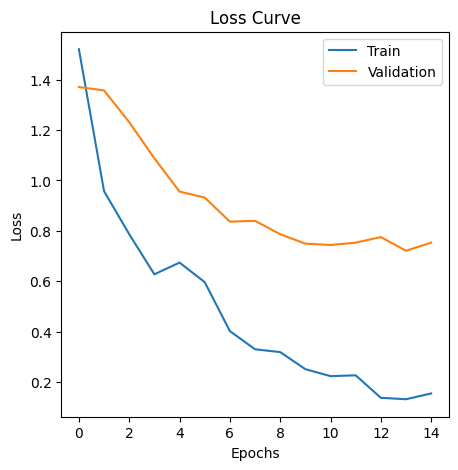

In [ ]:
train_losses,val_losses,train_accs,val_accs = history

plt.figure(figsize=(5,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

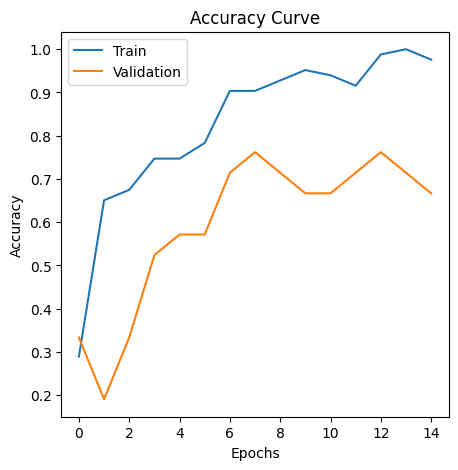

In [ ]:
plt.figure(figsize=(5,5))

plt.plot(train_accs,label="Train")
plt.plot(val_accs,label="Validation")

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Prediction on New Image

A previously unseen image is passed through the trained model and classified into one of the four categories.

In [ ]:
for idx in val_dataset.indices[:10]:
    print(dataset.samples[idx][0])

/content/drive/MyDrive/image-classifier-dataset/dataset/bottle/bottle_015.jpg
/content/drive/MyDrive/image-classifier-dataset/dataset/headphone/headphone_022.jpg
/content/drive/MyDrive/image-classifier-dataset/dataset/watch/watch_023.jpg
/content/drive/MyDrive/image-classifier-dataset/dataset/headphone/headphone_001.jpg
/content/drive/MyDrive/image-classifier-dataset/dataset/watch/watch_017.jpg
/content/drive/MyDrive/image-classifier-dataset/dataset/spiderman/spiderman_018.jpg
/content/drive/MyDrive/image-classifier-dataset/dataset/watch/watch_002.jpg
/content/drive/MyDrive/image-classifier-dataset/dataset/spiderman/spiderman_021.jpg
/content/drive/MyDrive/image-classifier-dataset/dataset/headphone/headphone_010.jpg
/content/drive/MyDrive/image-classifier-dataset/dataset/spiderman/spiderman_019.jpg


In [ ]:
image = Image.open('/content/drive/MyDrive/image-classifier-dataset/dataset/spiderman/spiderman_005.jpg').convert("RGB")


In [ ]:
img = transform(image)

img = img.unsqueeze(0)  # Add batch dimension

img = img.to(device)

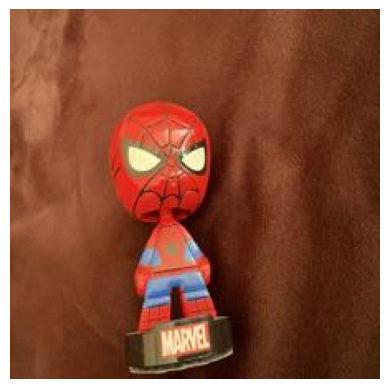

Prediction: spiderman


In [ ]:
model.eval()

with torch.no_grad():

    outputs = model(img)

    predicted_class = torch.argmax(outputs, dim=1)

predicted_label = dataset.classes[predicted_class.item()]


plt.imshow(image)
plt.axis("off")
plt.show()

print("Prediction:", predicted_label)

#Thankyou 👋